# Этап 2. Построение и анализ базовых моделей

В качестве базового алгоритма было выбрано решающее дерево (`DecisionTreeRegressor`)

# Этап 2.1 Добавление библиотек и чтение файлов:

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error as sklearn_mean_absolute_error, root_mean_squared_error as sklearn_root_mean_squared_error, r2_score as sklearn_r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Загружаем данные (устойчиво к рабочей директории ядра)
cwd = Path.cwd()
if (cwd / 'data' / 'processed').exists():
    processed_dir = cwd / 'data' / 'processed'
elif (cwd.parent / 'data' / 'processed').exists():
    processed_dir = cwd.parent / 'data' / 'processed'
else:
    # Последняя попытка — относительный путь
    processed_dir = Path('../data/processed')

train_path = processed_dir / 'train_one_hot_encoded.csv'
test_path = processed_dir / 'test_one_hot_encoded.csv'
val_path = processed_dir / 'validation_one_hot_encoded.csv'
#print('Используем processed_dir =', processed_dir.resolve())
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
val_df = pd.read_csv(val_path)
# Разделяем на признаки (X) и целевую переменную (y)
# (Убедитесь, что название колонки целевой переменной - 'charges')
target_col = 'charges'
original_target_col = 'charges_original'
feature_cols = [col for col in train_df.columns if col not in [target_col, original_target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
y_train_original = train_df[original_target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_test_original = test_df[original_target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]
y_val_original = val_df[original_target_col]

def inverse_target(values):
    return np.expm1(values)

def r2_original_scale(y_true_log, y_pred_log):
    return sklearn_r2_score(inverse_target(y_true_log), inverse_target(y_pred_log))

r2_original_scorer = make_scorer(r2_original_scale)

def r2_score(y_true_log, y_pred_log):
    return r2_original_scale(y_true_log, y_pred_log)

def mean_absolute_error(y_true_log, y_pred_log):
    return sklearn_mean_absolute_error(inverse_target(y_true_log), inverse_target(y_pred_log))

def root_mean_squared_error(y_true_log, y_pred_log):
    return sklearn_root_mean_squared_error(inverse_target(y_true_log), inverse_target(y_pred_log))

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер тренировочной выборки: (801, 8)
Размер тестовой выборки: (268, 8)
Размер валидационной выборки: (268, 8)


## Этап 2.2 Построим дерево решений без ограничения глубины.


Первый шаг в анализе решающих деревьев — построение модели «по умолчанию», то есть без каких-либо ограничений на рост структуры (без указания `max_depth`). Такое дерево продолжает делить выборку до тех пор, пока не выполнится стандартный критерий остановки. В результате модель может слишком подробно подстроиться под тренировочные данные и фактически запомнить отдельные наблюдения.

# зачем мы это делаем?

1. *Чтобы иметь точку отчета и показать эффект* **<До/После>** 
2. Зафиксировать худший сценарий.
3.  Показать проблему высокого разброса(High Variance)

и т.д.

In [16]:
# Обучаем дерево без ограничений
tree_unlimited = DecisionTreeRegressor(random_state=42)
tree_unlimited.fit(X_train, y_train)

# Считаем предсказания
y_train_pred = tree_unlimited.predict(X_train)
y_val_pred = tree_unlimited.predict(X_val)

# Проверяем метрики переобучения
print("Метрики на Train (должны быть идеальными):")
print(f"R2: {r2_score(y_train, y_train_pred):.4f} | MAE: ${mean_absolute_error(y_train, y_train_pred):.2f} | RMSE: ${root_mean_squared_error(y_train, y_train_pred):.2f}")

print("\nМетрики на Validation (покажут реальное качество):")
print(f"R2: {r2_score(y_val, y_val_pred):.4f} | MAE: ${mean_absolute_error(y_val, y_val_pred):.2f} | RMSE: ${root_mean_squared_error(y_val, y_val_pred):.2f}")

Метрики на Train (должны быть идеальными):
R2: 0.9992 | MAE: $15.61 | RMSE: $348.18

Метрики на Validation (покажут реальное качество):
R2: 0.6741 | MAE: $3474.72 | RMSE: $7043.96


## Визуализация модели

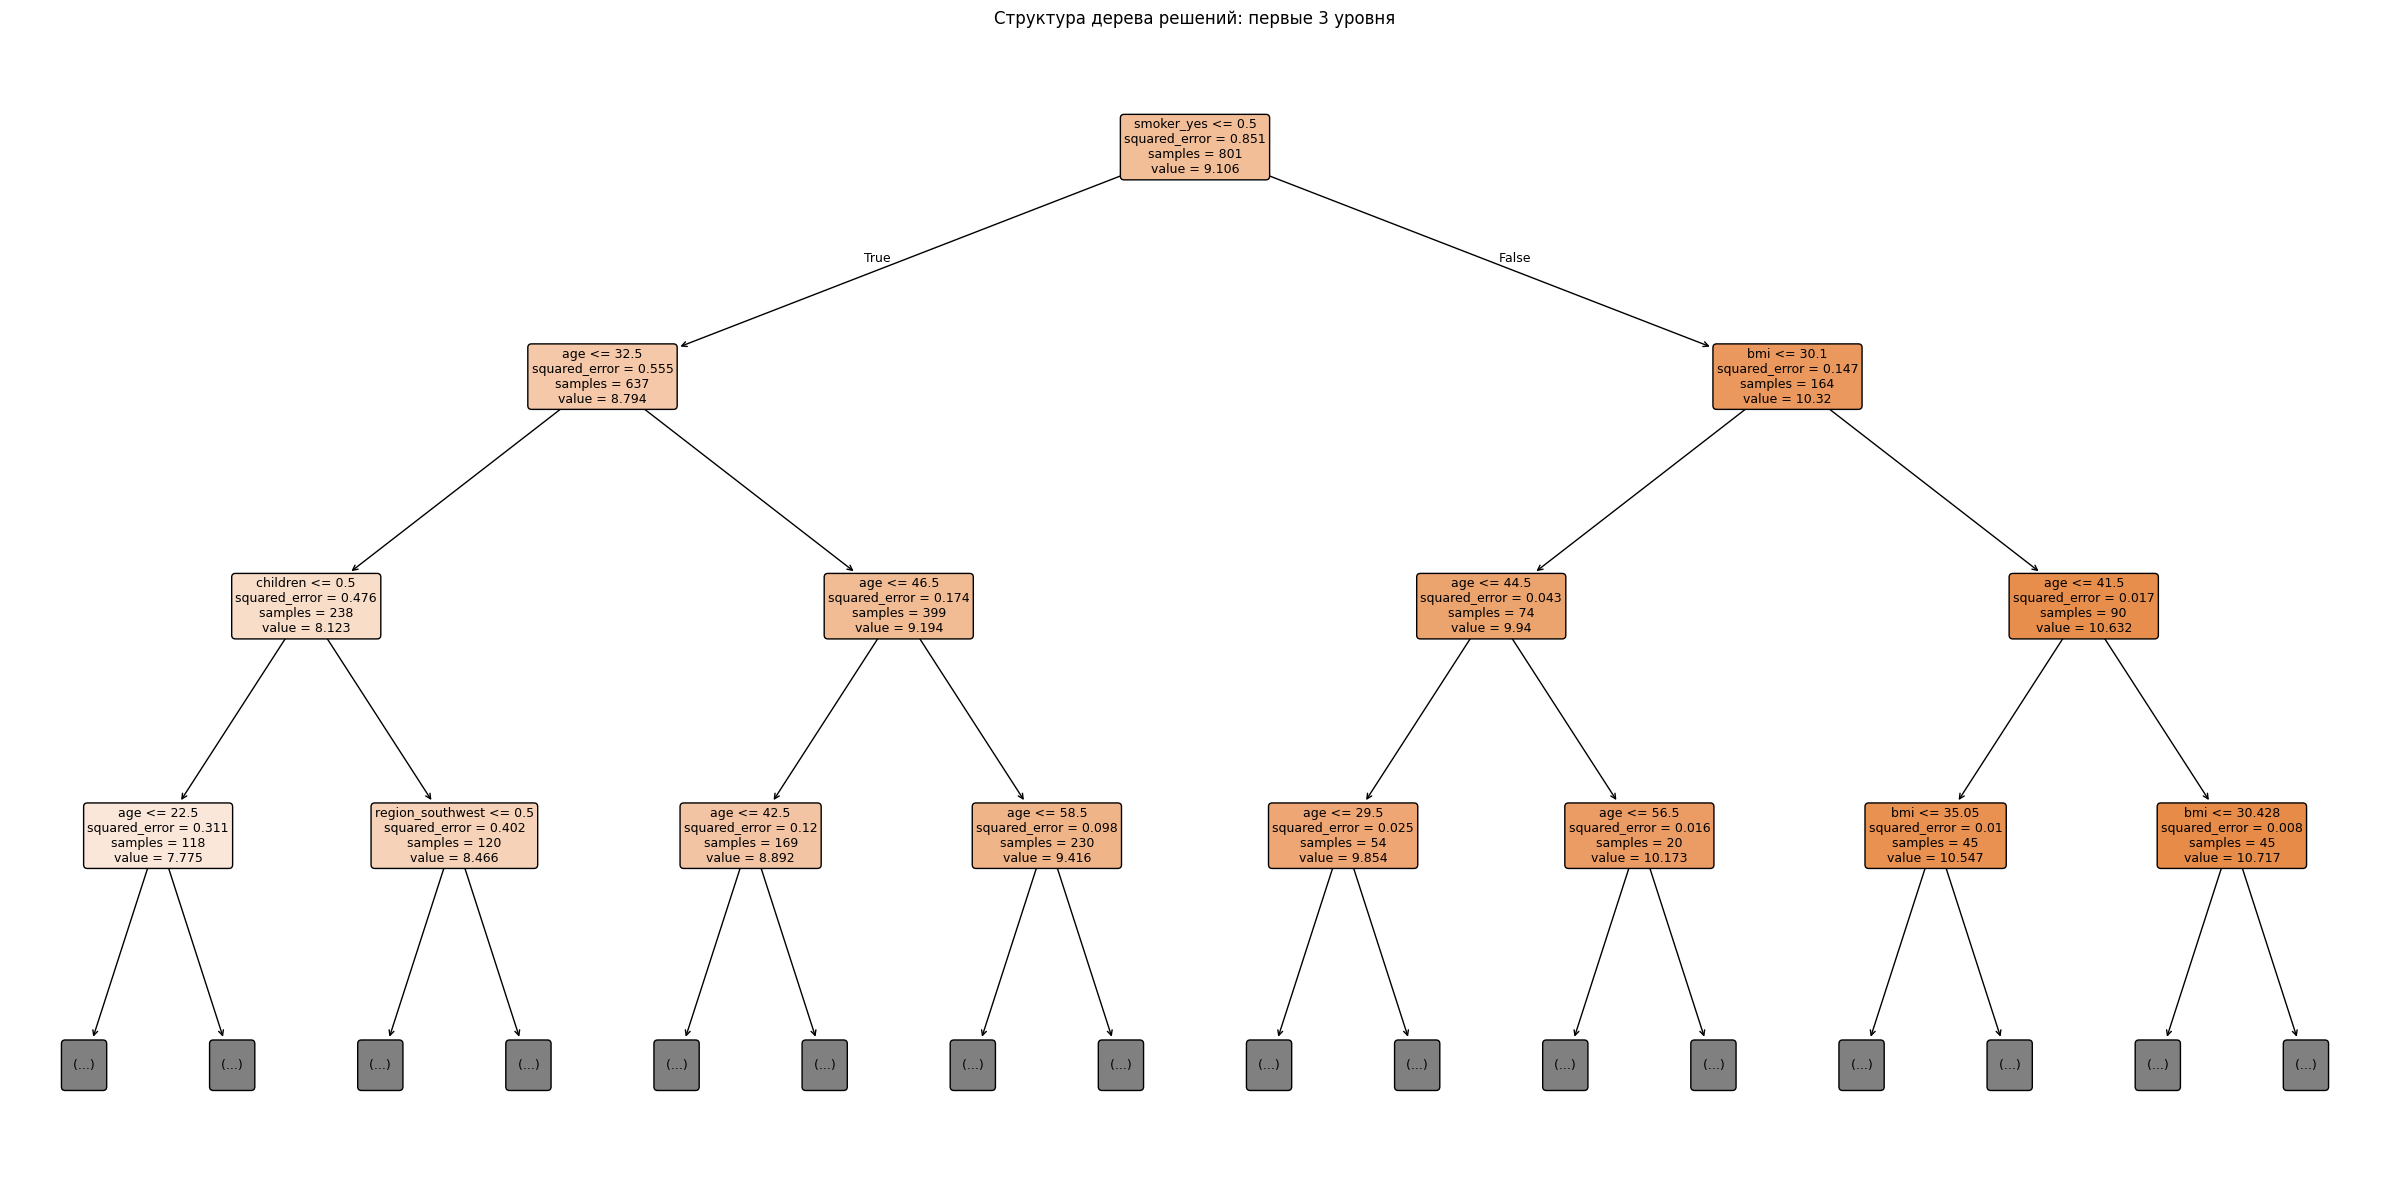

In [17]:
from sklearn.tree import plot_tree

figures_dir = processed_dir.parent.parent / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(24, 12))
plot_tree(
    tree_unlimited,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Структура дерева решений: первые 3 уровня')
plt.tight_layout()
plt.savefig(figures_dir / 'decision_tree_structure_first_3_levels.png', dpi=200, bbox_inches='tight')
plt.show()


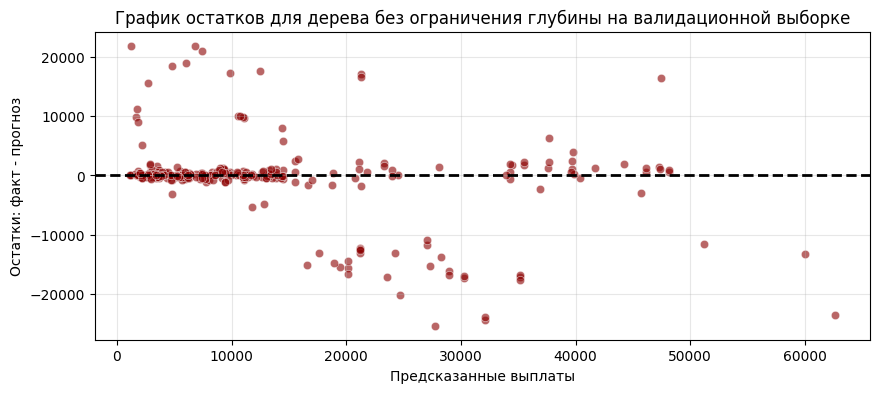

In [18]:
# График остатков для дерева без ограничения глубины на валидации
residuals_unlimited = inverse_target(y_val) - inverse_target(y_val_pred)
plt.figure(figsize=(10, 4))
sns.scatterplot(x=inverse_target(y_val_pred), y=residuals_unlimited, alpha=0.6, color='darkred')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('График остатков для дерева без ограничения глубины на валидационной выборке')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.show()

#### Мы видим, что метрики на Train идеальны, модель подстроилась под каждого конкретного человека из обучающего набора и запомнила его идеальную стоимость. Но, как только появляются новые пациенты, она начинает допускать огромные ошибки. Хотя на большинстве значений она показывает примерно правильные значения, но если модель начинает врать - то врет сильно.

## Что означают метрики R2 и MAE?

Мы будем использовать 4 вида метрик:

1. **$MAE$(средняя абсолютная ошибка)** - находит среднее арифметическое всех ошибок(если модель ошиблась на 100 долларов вниз или вверх, для нее это одна и та же стоимость - 100 единиц)
2. **$MSE$(средняя квадратичная ошибка)** - возводит в квадрат ошибку перед усреднением. Измеряется в "квадратичных долларах" ($\$^2$)
3. **$RMSE$(корень из средней квадратичной ошибки)** - берет корень от MSE, то есть считывает также все в квадрате, но от среднего числа берет корень. RMSE очень чувствителен к крупным ошибкам (выбросам)
4. **$R^2$ (R2, коэффициент детерминации)** - Показывает долю объясненной дисперсии. Сравнивает модель с глупым предсказанием среднего значения для каждого пациента. Обычно от 0 до 1, но бывает и отрицательные значения(то есть лучше было бы использовать среднее значение для всех, чем использовать такой вариант).
    * $R^2 = 1$: Идеальное предсказание.
   * $R^2 = 0$: Модель работает на уровне предсказания константы (среднего).
   * $R^2 < 0$: Модель работает хуже, чем простое предсказание среднего значения.

### Этап 2.3. Оптимизация гиперпараметров и борьба с переобучением

Как продемонстрировал предыдущий шаг, дерево решений без ограничений глубины переобучается: оно идеально запоминает тренировочный набор, но теряет обобщающую способность на новых данных. Чтобы решить эту проблему, необходимо провести регуляризацию (подрезку) дерева. Главным гиперпараметром в данном случае выступает максимальная глубина (`max_depth`).

В этой ячейке мы реализуем процесс ручного поиска оптимальной глубины:
1. Обучим последовательность моделей с ограничением `max_depth` в диапазоне от 1 до 15.
2. Для каждого шага посчитаем метрику качества $R^2$ на обучающей выборке (`Train`) и на валидационной выборке (`Validation`).
3. Построим график кривых обучения (Learning Curves).


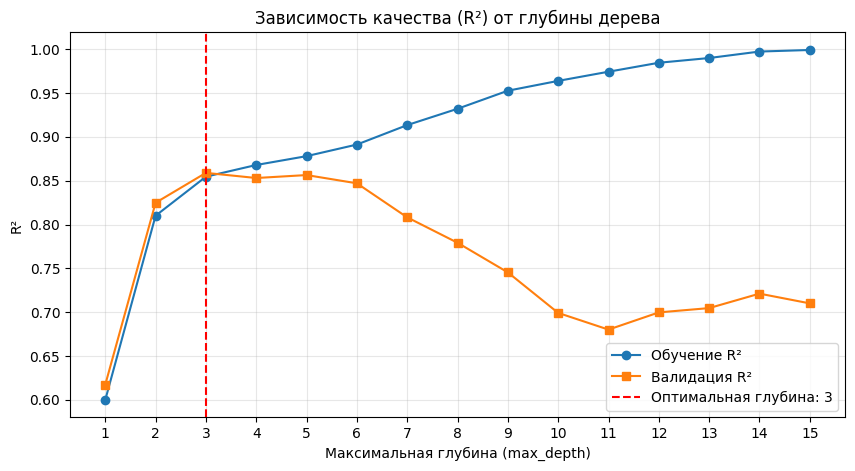

Оптимальная глубина дерева (max_depth): 3
Максимальный R² на валидации: 0.8590


In [19]:
depths = range(1, 16)
train_r2_scores = []
val_r2_scores = []

# Обучаем деревья с разной глубиной и записываем их R2
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    train_r2_scores.append(r2_score(y_train, tree.predict(X_train)))
    val_r2_scores.append(r2_score(y_val, tree.predict(X_val)))

# Ищем глубину с максимальным R2 на валидации
best_depth = depths[np.argmax(val_r2_scores)]
best_val_score = max(val_r2_scores)

# Строим график зависимости качества от глубины
plt.figure(figsize=(10, 5))
plt.plot(depths, train_r2_scores, label='Обучение R²', marker='o')
plt.plot(depths, val_r2_scores, label='Валидация R²', marker='s')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Оптимальная глубина: {best_depth}')
plt.title('Зависимость качества (R²) от глубины дерева')
plt.xlabel('Максимальная глубина (max_depth)')
plt.ylabel('R²')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оптимальная глубина дерева (max_depth): {best_depth}")
print(f"Максимальный R² на валидации: {best_val_score:.4f}")

### Этап 2.4. Подбор гиперпараметров через KFold и GridSearchCV

Ручной график по `max_depth` показал, где начинается переобучение. Дальше выполним двухэтапный подбор гиперпараметров дерева с помощью `GridSearchCV` и `KFold`.

Сначала используем широкую сетку параметров, чтобы найти примерную область хороших значений. Затем строим более узкую сетку вокруг найденных параметров и повторяем поиск. Подбор делается только на `Train`, а `Validation` используется для проверки лучшей модели.

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

coarse_param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12, 16, None],
    'min_samples_split': [2, 10, 20, 40],
    'min_samples_leaf': [1, 4, 8, 16],
    'criterion': ['squared_error', 'absolute_error'],
    'ccp_alpha': [0.0, 0.0001]
}

coarse_grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=coarse_param_grid,
    scoring=r2_original_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

coarse_grid_search.fit(X_train, y_train)
coarse_best_params = coarse_grid_search.best_params_

print('Лучшие параметры после широкого поиска:')
print(coarse_best_params)
print(f"Лучший средний R² после широкого поиска: {coarse_grid_search.best_score_:.4f}")

def values_around(best_value, radius, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1)
    return [int(value) for value in values if lower_bound <= value <= upper_bound]

best_depth = coarse_best_params['max_depth']
if best_depth is None:
    refined_depths = [12, 16, 20, None]
else:
    refined_depths = values_around(best_depth, radius=2, lower_bound=1, upper_bound=30)

best_split = coarse_best_params['min_samples_split']
best_leaf = coarse_best_params['min_samples_leaf']
best_alpha = coarse_best_params['ccp_alpha']

refined_param_grid = {
    'max_depth': refined_depths,
    'min_samples_split': values_around(best_split, radius=5, lower_bound=2, upper_bound=80),
    'min_samples_leaf': values_around(best_leaf, radius=2, lower_bound=1, upper_bound=40),
    'criterion': [coarse_best_params['criterion']],
    'ccp_alpha': sorted({0.0, best_alpha / 10, best_alpha, best_alpha * 10})
}

refined_grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=refined_param_grid,
    scoring=r2_original_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

refined_grid_search.fit(X_train, y_train)

# Дальше в ноутбуке используем именно результат уточненного поиска.
grid_search = refined_grid_search

best_tree_cv = grid_search.best_estimator_
y_val_pred_grid = best_tree_cv.predict(X_val)

print('\nЛучшие параметры после уточненного поиска:')
print(grid_search.best_params_)
print(f"Лучший средний R² после уточненного поиска: {grid_search.best_score_:.4f}")
print('\nМетрики модели GridSearchCV на валидационной выборке:')
print(f"Валидация R2:   {r2_score(y_val, y_val_pred_grid):.4f}")
print(f"Валидация MAE:  ${mean_absolute_error(y_val, y_val_pred_grid):.2f}")
print(f"Валидация RMSE: ${root_mean_squared_error(y_val, y_val_pred_grid):.2f}")

coarse_cv_results = pd.DataFrame(coarse_grid_search.cv_results_)
refined_cv_results = pd.DataFrame(refined_grid_search.cv_results_)

refined_cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)


Лучшие параметры после широкого поиска:
{'ccp_alpha': 0.0001, 'criterion': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 2}
Лучший средний R² после широкого поиска: 0.8398

Лучшие параметры после уточненного поиска:
{'ccp_alpha': 0.0001, 'criterion': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 6, 'min_samples_split': 2}
Лучший средний R² после уточненного поиска: 0.8401

Метрики модели GridSearchCV на валидационной выборке:
Валидация R2:   0.8664
Валидация MAE:  $2259.85
Валидация RMSE: $4510.33


,mean_test_score,mean_train_score,params
360,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
365,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
361,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
363,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
362,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
364,0.840072,0.865271,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
367,0.839878,0.865169,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
371,0.839878,0.865169,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
369,0.839878,0.865169,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."
370,0.839878,0.865169,"{'ccp_alpha': 0.0001, 'criterion': 'squared_er..."


### Этап 2.5. Финальное тестирование модели и визуальный анализ ошибок

После ручного анализа `max_depth` был выполнен полноценный подбор гиперпараметров через `GridSearchCV` и `KFold`. Лучшая комбинация параметров выбирается только на тренировочной выборке, затем проверяется на `Validation`.
Для финальной проверки обучаем дерево с найденными параметрами на объединенных тренировочной и валидационной выборках и только после этого оцениваем качество на отложенной тестовой выборке.

В данной ячейке мы переходим к финальному этапу построения базовой модели:
1. Обучаем итоговое дерево решений с лучшими параметрами из `GridSearchCV`.
2. Впервые извлекаем из «сейфа» отложенную **тестовую выборку (`Test`)** и делаем по ней предсказания. Метрики ($R^2$, MAE, RMSE) на тесте покажут реальное, честное качество работы модели в продакшене.
3. Строим **график остатков** для визуального анализа характера ошибок.



=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Тест R2:   0.8364
Тест MAE:  $2245.59
Тест RMSE: $4614.23


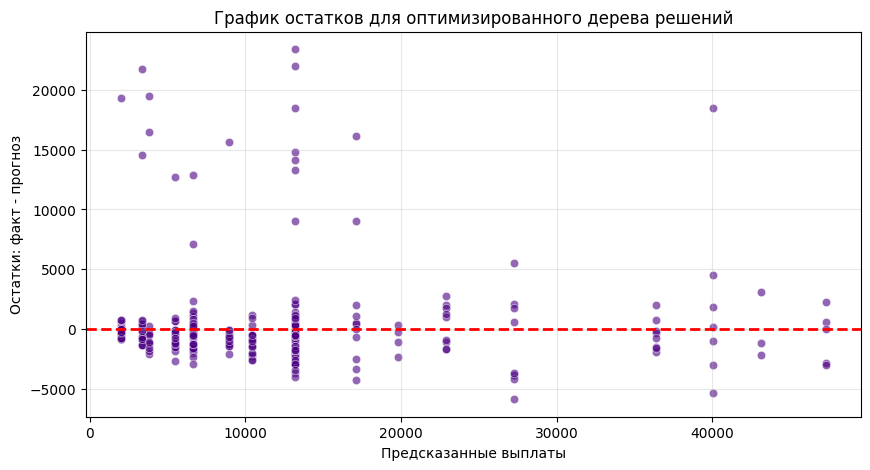

In [21]:
# Дообучаем лучшую модель GridSearchCV на объединенных train и validation данных.
# Тестовая выборка остается нетронутой до финальной проверки.
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_tree = DecisionTreeRegressor(
    **grid_search.best_params_,
    random_state=42
)
best_tree.fit(X_train_full, y_train_full)

# Финальные предсказания на отложенной тестовой выборке.
y_test_pred = best_tree.predict(X_test)

print('=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ===')
print(f"Тест R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"Тест MAE:  ${mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"Тест RMSE: ${root_mean_squared_error(y_test, y_test_pred):.2f}")

residuals = inverse_target(y_test) - inverse_target(y_test_pred)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=inverse_target(y_test_pred), y=residuals, alpha=0.6, color='indigo')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков для оптимизированного дерева решений')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.show()


### Этап 2.6. Интерпретация модели: Важность признаков (Feature Importance)
Решающие деревья обладают встроенным механизмом оценки важности факторов. Посмотрим, какие именно характеристики клиентов медицинского страхования оказались ключевыми для принятия решений нашей оптимальной моделью.

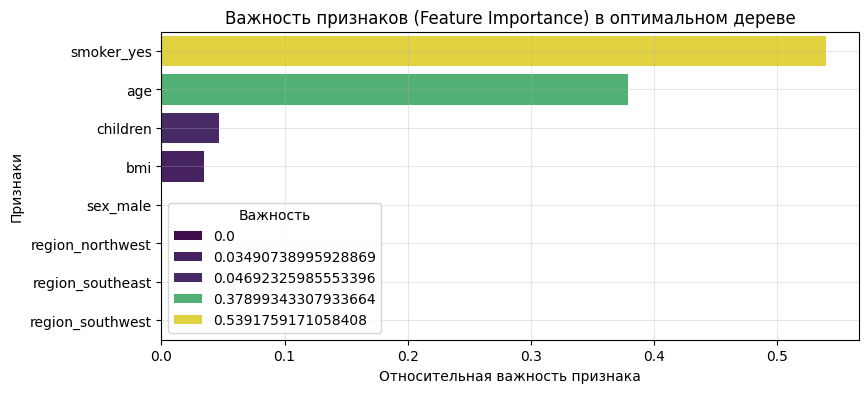

         Признак  Важность
      smoker_yes  0.539176
             age  0.378993
        children  0.046923
             bmi  0.034907
        sex_male  0.000000
region_northwest  0.000000
region_southeast  0.000000
region_southwest  0.000000


In [22]:
# Получаем важность признаков из финального оптимального дерева
importances = best_tree.feature_importances_
features = X_train.columns

# Создаем датафрейм для удобства визуализации
importance_df = pd.DataFrame({
    'Признак': features,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график
plt.figure(figsize=(9, 4))
sns.barplot(x='Важность', y='Признак', data=importance_df, palette='viridis',hue='Важность')
plt.title('Важность признаков (Feature Importance) в оптимальном дереве')
plt.xlabel('Относительная важность признака')
plt.ylabel('Признаки')
plt.grid(True, alpha=0.3)
plt.show()

# Выводим текстовые значения
print(importance_df.to_string(index=False))